### Инициализация проекта

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings

In [92]:
data = pd.read_csv('data/smoke_detector_task.csv')

### Исследование исходных данных

In [93]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62630 entries, 0 to 62629
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      62630 non-null  int64  
 1   UTC             62630 non-null  int64  
 2   Temperature[C]  62484 non-null  float64
 3   Humidity[%]     62383 non-null  float64
 4   TVOC[ppb]       62009 non-null  float64
 5   eCO2[ppm]       62305 non-null  float64
 6   Raw H2          62519 non-null  float64
 7   Raw Ethanol     62630 non-null  int64  
 8   Pressure[hPa]   62603 non-null  float64
 9   PM1.0           62630 non-null  float64
 10  PM2.5           62313 non-null  float64
 11  NC0.5           62630 non-null  float64
 12  NC1.0           62378 non-null  float64
 13  NC2.5           62630 non-null  float64
 14  CNT             62630 non-null  int64  
 15  Fire Alarm      62630 non-null  object 
dtypes: float64(11), int64(4), object(1)
memory usage: 7.6+ MB


2 лишних поля: "Unnamed: 0" и "CNT" - не несут никакой смысловой нагрузки, "CNT" - просто счётчик от 1 и до длины датасета

In [94]:
data = data.drop("Unnamed: 0", axis=1)
data = data.drop("CNT", axis=1)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62630 entries, 0 to 62629
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   UTC             62630 non-null  int64  
 1   Temperature[C]  62484 non-null  float64
 2   Humidity[%]     62383 non-null  float64
 3   TVOC[ppb]       62009 non-null  float64
 4   eCO2[ppm]       62305 non-null  float64
 5   Raw H2          62519 non-null  float64
 6   Raw Ethanol     62630 non-null  int64  
 7   Pressure[hPa]   62603 non-null  float64
 8   PM1.0           62630 non-null  float64
 9   PM2.5           62313 non-null  float64
 10  NC0.5           62630 non-null  float64
 11  NC1.0           62378 non-null  float64
 12  NC2.5           62630 non-null  float64
 13  Fire Alarm      62630 non-null  object 
dtypes: float64(11), int64(2), object(1)
memory usage: 6.7+ MB


In [95]:
data.describe()

,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5
count,6.263000e+04,62484.000000,62383.000000,62009.000000,62305.000000,62519.000000,62630.000000,62603.000000,62630.000000,62313.000000,62630.000000,62378.000000,62630.000000
mean,1.654792e+09,15.972252,48.536969,1944.124030,670.574994,12942.383835,19754.257912,938.627644,100.594309,184.443467,491.463608,203.382660,80.049042
std,1.100025e+05,14.361206,8.868993,7819.668069,1909.675941,272.531480,609.513156,1.331169,922.524245,1976.590473,4265.661251,2214.719662,1083.383189
min,1.654712e+09,-22.010000,10.740000,0.000000,400.000000,10668.000000,15317.000000,930.852000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.654743e+09,11.000500,47.530000,130.000000,400.000000,12830.000000,19435.000000,938.700000,1.280000,1.340000,8.820000,1.384000,0.033000
50%,1.654762e+09,20.130000,50.140000,981.000000,400.000000,12924.000000,19501.000000,938.816000,1.810000,1.880000,12.450000,1.942000,0.044000
75%,1.654778e+09,25.410000,53.240000,1189.000000,438.000000,13108.000000,20078.000000,939.417000,2.090000,2.180000,14.420000,2.249000,0.051000
max,1.655130e+09,59.930000,75.200000,60000.000000,60000.000000,13803.000000,21410.000000,939.861000,14333.690000,45432.260000,61482.030000,51914.680000,30026.438000


In [96]:
data.head(20)

,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,Fire Alarm
0,1654733331,20.000,57.36,0.0,400.0,12306.0,18520,939.735,0.00,0.00,0.0,0.000,0.000,No
1,1654733332,20.015,56.67,0.0,400.0,12345.0,18651,939.744,0.00,0.00,0.0,0.000,0.000,No
2,1654733333,20.029,55.96,0.0,400.0,12374.0,18764,939.738,0.00,0.00,0.0,0.000,0.000,No
3,1654733334,20.044,55.28,0.0,400.0,12390.0,18849,939.736,0.00,0.00,0.0,0.000,0.000,No
4,1654733335,20.059,54.69,0.0,400.0,12403.0,18921,939.744,0.00,0.00,0.0,0.000,0.000,No
5,1654733336,20.073,54.12,0.0,400.0,12419.0,18998,939.725,0.00,0.00,0.0,0.000,0.000,No
6,1654733337,20.088,53.61,0.0,400.0,12432.0,19058,939.738,0.00,0.00,0.0,0.000,0.000,No
7,1654733338,20.103,53.20,0.0,400.0,12439.0,19114,939.758,0.00,0.00,0.0,0.000,0.000,No
8,1654733339,20.117,52.81,0.0,400.0,12448.0,19155,939.758,0.00,0.00,0.0,0.000,0.000,No
9,1654733340,20.132,52.46,0.0,400.0,12453.0,19195,939.756,0.90,3.78,0.0,4.369,2.780,No


<font size=4>
Датасет содержит следующие поля:

- `UTC` — время
- `Temperature[C]` — температура
- `Humidity[%]` — влажность
- `TVOC[ppb]` — содержание летучих органических соединений в воздухе и показания в виде концентрации TVOC - в частях на миллиард (ppb)
- `eCO2[ppm]` — концентрация молекул углекислого газа (CO2) в воздухе
- `Raw H2` — концентрации водорода (H₂)
- `Raw Ethanol` — сырое (необработанное) значение концентрации этанола (C₂H₅OH)
- `Pressure[hPa]` — давление воздуха, измеряемое в гектопаскалях (hPa)
- `PM1.0` — твёрдые частицы в воздухе ≤ 1.0 мкм (ультрамелкие частицы)
- `PM2.5` — частицы ≤ 2.5 мкм (мелкие частицы, опасные для здоровья)
- `NC0.5` — количество частиц определённого размера, концентрация частиц ≤ 0.5 мкм
- `NC1.0` — концентрация частиц ≤ 1.0 мкм
- `NC2.5` — концентрация частиц ≤ 2.5 мкм
- `Fire Alarm` — сработал ли датчик
</font>

Заключение по исходным данным:
- поле "Fire Alarm" следует перевести из типа object в тип bool
- поля "TVOC[ppb]", "eCO2[ppm]", "Raw H2" следует перевести из типа float в тип int
- "UTC" перевести в datetime

### Заполнение пропусков

In [97]:
(data.isna().sum() / data.shape[0] * 100).sort_values(ascending=False)

TVOC[ppb]         0.991538
eCO2[ppm]         0.518921
PM2.5             0.506147
NC1.0             0.402363
Humidity[%]       0.394380
Temperature[C]    0.233115
Raw H2            0.177231
Pressure[hPa]     0.043110
UTC               0.000000
Raw Ethanol       0.000000
PM1.0             0.000000
NC0.5             0.000000
NC2.5             0.000000
Fire Alarm        0.000000
dtype: float64

### TVOC[ppb] пропуски

Имеются выбросы и нулевые замеры, вероятнее всего из-за:
- **Датчик обнуляется во время авто-калибровки** - самая вероятная причина
- В воздухе действительно нет ЛОС (или их уровень ниже порога чувствительности)
- Датчик загрязнён или неисправен
- Проблемы с питанием или связью
- Программные фильтры или алгоритмы сглаживания данных

Пропуски заменены на среднее между первым и третьим квартилями, дабы не учитывать выбросы и нулевые замеры.

In [98]:
iqr_mean = (data["TVOC[ppb]"].quantile(0.25) + data["TVOC[ppb]"].quantile(0.75)) / 2
data.fillna({"TVOC[ppb]": iqr_mean}, inplace=True)
data['TVOC[ppb]'].value_counts()

TVOC[ppb]
0.0        2675
60000.0     921
659.5       621
1141.0      316
1136.0      261
           ... 
396.0         1
394.0         1
405.0         1
410.0         1
418.0         1
Name: count, Length: 1967, dtype: int64

### eCO2[ppm] пропуски

Нулевые значения отсутствуют, но есть выбросы.

In [99]:
iqr_mean = (data['eCO2[ppm]'].quantile(0.25) + data['eCO2[ppm]'].quantile(0.75)) / 2
data.fillna({"eCO2[ppm]": iqr_mean}, inplace=True)
data["eCO2[ppm]"].value_counts()

eCO2[ppm]
400.0     31771
404.0       938
401.0       917
406.0       911
408.0       892
          ...  
2625.0        1
2572.0        1
2911.0        1
2494.0        1
2722.0        1
Name: count, Length: 1712, dtype: int64

### Продолжительность замеров в днях в датасете

In [100]:
(1.655130e+09 - 1.654712e+09) / 60 / 60 / 24

4.837962962962963

### PM2.5 пропуски

Имеются выбросы и нулевые замеры, причины:
- **В воздухе действительно нет частиц (или их уровень ниже порога чувствительности)** - самая вероятная причина нулевых значений
- Временные сбои или калибровка датчика
- **Загрязнения или сбой в работе сенсора** - самая вероятная причины выбросов
- Проблемы с питанием или соединением датчика
- Датчик фильтрует аномальные данные

Пропуски заменены на среднее между первым и третьим квартилями, дабы не учитывать выбросы и нулевые замеры.

In [101]:
iqr_mean = (data["PM2.5"].quantile(0.25) + data["PM2.5"].quantile(0.75)) / 2
data.fillna({"PM2.5": iqr_mean}, inplace=True)
data["PM2.5"].value_counts()

PM2.5
1.86    635
1.82    633
2.03    625
1.83    611
1.99    592
       ... 
5.63      1
5.99      1
6.45      1
7.50      1
8.03      1
Name: count, Length: 1350, dtype: int64

### NC1.0 пропуски

In [102]:
iqr_mean = (data["NC1.0"].quantile(0.25) + data["NC1.0"].quantile(0.75)) / 2
data.fillna({"NC1.0": iqr_mean}, inplace=True)
data["NC1.0"].value_counts()

NC1.0
1.8165     252
1.9050      84
1.9760      84
1.9950      82
1.9910      82
          ... 
6.8140       1
9.1450       1
11.3190      1
12.5850      1
13.9650      1
Name: count, Length: 4110, dtype: int64

### Humidity[%] пропуски

Выбросов нет, стандартное отклонение 8.868993, минимум 10, максимум 75, среднее значение находится в диапазоне нормы для практически любого типа помещения, поэтому можно использовать среднее значение.

In [103]:
data.fillna({"Humidity[%]": data["Humidity[%]"].mean()}, inplace=True)
data["Humidity[%]"].value_counts()

Humidity[%]
48.536969    247
47.500000    130
47.450000    130
53.120000    126
47.860000    126
            ... 
18.680000      1
18.140000      1
16.400000      1
16.830000      1
16.910000      1
Name: count, Length: 3887, dtype: int64

### Temperature[C] пропуски

Явные выбросы также отсутсвуют, но максимальная температура в 60 может являться выбросом или аномалией, поэтому для можно взять квартиль2, различия между квартилем 2 и 1, 2 и 3 примерно равны, среднее значение не подходит, стандартное отклонение слишком велико.

In [104]:
data.fillna({"Temperature[C]": data["Temperature[C]"].quantile(0.5)}, inplace=True)
data["Temperature[C]"].value_counts()

Temperature[C]
 24.480    222
 24.510    206
 24.470    193
 26.950    191
 26.980    189
          ... 
-7.206       1
-7.203       1
-7.199       1
-7.193       1
-20.390      1
Name: count, Length: 21636, dtype: int64

### Raw H2 пропуски

Минимальное и максимальное значения практически не различимы, стандартное отклонение невелико, среднее зачение и квартиль 2 примерно равны, можно использовать квартиль 2.

In [105]:
data.fillna({"Raw H2": data["Raw H2"].quantile(0.5)}, inplace=True)
data["Raw H2"].value_counts()

Raw H2
12969.0    328
12779.0    319
12786.0    315
12784.0    310
12924.0    309
          ... 
12360.0      1
12332.0      1
12322.0      1
12333.0      1
12499.0      1
Name: count, Length: 1830, dtype: int64

### Pressure[hPa] пропуски

Среднее значение и квартиль 2 равны, используем квартиль 2.

In [106]:
data.fillna({"Pressure[hPa]": data["Pressure[hPa]"].quantile(0.5)}, inplace=True)
data["Pressure[hPa]"].value_counts()

Pressure[hPa]
938.709    304
938.706    284
938.716    278
938.711    266
938.710    266
          ... 
930.871      1
930.868      1
930.857      1
930.862      1
930.858      1
Name: count, Length: 2213, dtype: int64

### Итог

In [107]:
(data.isna().sum()/data.shape[0]*100).sort_values(ascending=False)

UTC               0.0
Temperature[C]    0.0
Humidity[%]       0.0
TVOC[ppb]         0.0
eCO2[ppm]         0.0
Raw H2            0.0
Raw Ethanol       0.0
Pressure[hPa]     0.0
PM1.0             0.0
PM2.5             0.0
NC0.5             0.0
NC1.0             0.0
NC2.5             0.0
Fire Alarm        0.0
dtype: float64

### Исправление типов данных

In [108]:
data['TVOC[ppb]'] = data['TVOC[ppb]'].astype(int)
data['eCO2[ppm]'] = data['eCO2[ppm]'].astype(int)
data['Raw H2'] = data['Raw H2'].astype(int)

In [109]:
data["Fire Alarm"] = data["Fire Alarm"].map({"Yes": True, "No": False})


In [110]:
data["UTC"] = pd.to_datetime(data["UTC"], unit="s")

In [111]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62630 entries, 0 to 62629
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   UTC             62630 non-null  datetime64[ns]
 1   Temperature[C]  62630 non-null  float64       
 2   Humidity[%]     62630 non-null  float64       
 3   TVOC[ppb]       62630 non-null  int64         
 4   eCO2[ppm]       62630 non-null  int64         
 5   Raw H2          62630 non-null  int64         
 6   Raw Ethanol     62630 non-null  int64         
 7   Pressure[hPa]   62630 non-null  float64       
 8   PM1.0           62630 non-null  float64       
 9   PM2.5           62630 non-null  float64       
 10  NC0.5           62630 non-null  float64       
 11  NC1.0           62630 non-null  float64       
 12  NC2.5           62630 non-null  float64       
 13  Fire Alarm      62630 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(8), int64(4)
me

### **Проверка "очищенных" данных**

In [112]:
data.duplicated().sum()

np.int64(0)

In [113]:
data.head(10)

,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,Fire Alarm
0,2022-06-09 00:08:51,20.000,57.36,0,400,12306,18520,939.735,0.0,0.00,0.0,0.000,0.00,False
1,2022-06-09 00:08:52,20.015,56.67,0,400,12345,18651,939.744,0.0,0.00,0.0,0.000,0.00,False
2,2022-06-09 00:08:53,20.029,55.96,0,400,12374,18764,939.738,0.0,0.00,0.0,0.000,0.00,False
3,2022-06-09 00:08:54,20.044,55.28,0,400,12390,18849,939.736,0.0,0.00,0.0,0.000,0.00,False
4,2022-06-09 00:08:55,20.059,54.69,0,400,12403,18921,939.744,0.0,0.00,0.0,0.000,0.00,False
5,2022-06-09 00:08:56,20.073,54.12,0,400,12419,18998,939.725,0.0,0.00,0.0,0.000,0.00,False
6,2022-06-09 00:08:57,20.088,53.61,0,400,12432,19058,939.738,0.0,0.00,0.0,0.000,0.00,False
7,2022-06-09 00:08:58,20.103,53.20,0,400,12439,19114,939.758,0.0,0.00,0.0,0.000,0.00,False
8,2022-06-09 00:08:59,20.117,52.81,0,400,12448,19155,939.758,0.0,0.00,0.0,0.000,0.00,False
9,2022-06-09 00:09:00,20.132,52.46,0,400,12453,19195,939.756,0.9,3.78,0.0,4.369,2.78,False


In [114]:
data.describe()

,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5
count,62630,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000
mean,2022-06-09 16:27:46.184272384,15.981944,48.536969,1931.381542,669.269519,12942.351253,19754.257912,938.627725,100.594309,183.518820,491.463608,202.571633,80.049042
min,2022-06-08 18:16:27,-22.010000,10.740000,0.000000,400.000000,10668.000000,15317.000000,930.852000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2022-06-09 02:54:04.249999872,11.074000,47.540000,132.000000,400.000000,12830.000000,19435.000000,938.700000,1.280000,1.350000,8.820000,1.392000,0.033000
50%,2022-06-09 08:05:19.500000,20.130000,50.120000,958.000000,400.000000,12924.000000,19501.000000,938.816000,1.810000,1.880000,12.450000,1.940000,0.044000
75%,2022-06-09 12:26:16.750000128,25.400000,53.240000,1187.000000,437.000000,13108.000000,20078.000000,939.417000,2.090000,2.180000,14.420000,2.247000,0.051000
max,2022-06-13 14:20:51,59.930000,75.200000,60000.000000,60000.000000,13803.000000,21410.000000,939.861000,14333.690000,45432.260000,61482.030000,51914.680000,30026.438000
std,NaN,14.345858,8.851486,7781.845220,1904.800331,272.290962,609.513156,1.330888,922.524245,1971.624439,4265.661251,2210.296325,1083.383189


# EDA

Поля, где явно выражены выбросы:
- TVOC[ppb]
- eCO2[ppm]
- PM1.0
- PM2.5	
- NC0.5	
- NC1.0
- NC2.5

In [115]:
data.describe()[['TVOC[ppb]','eCO2[ppm]','PM1.0','PM2.5','NC0.5', 'NC1.0', 'NC2.5']]

,TVOC[ppb],eCO2[ppm],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5
count,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000
mean,1931.381542,669.269519,100.594309,183.518820,491.463608,202.571633,80.049042
min,0.000000,400.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,132.000000,400.000000,1.280000,1.350000,8.820000,1.392000,0.033000
50%,958.000000,400.000000,1.810000,1.880000,12.450000,1.940000,0.044000
75%,1187.000000,437.000000,2.090000,2.180000,14.420000,2.247000,0.051000
max,60000.000000,60000.000000,14333.690000,45432.260000,61482.030000,51914.680000,30026.438000
std,7781.845220,1904.800331,922.524245,1971.624439,4265.661251,2210.296325,1083.383189


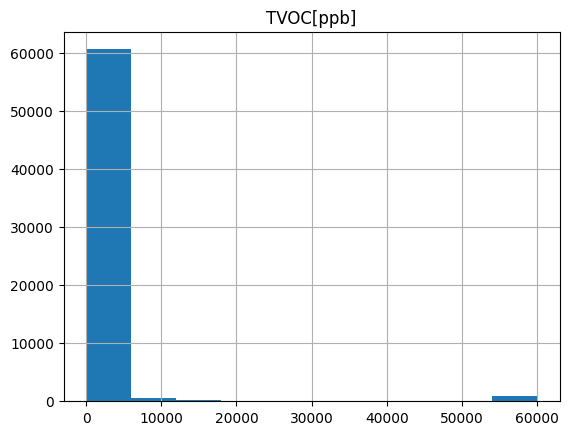

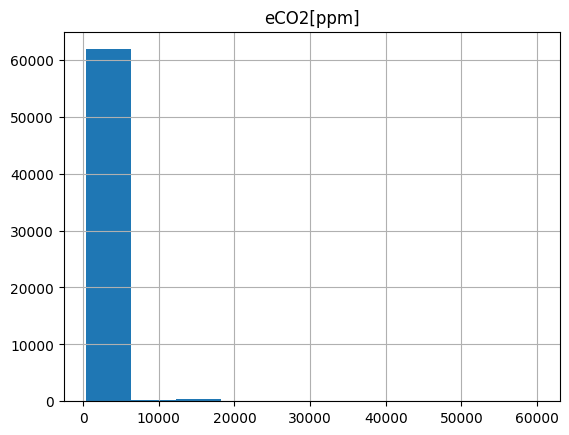

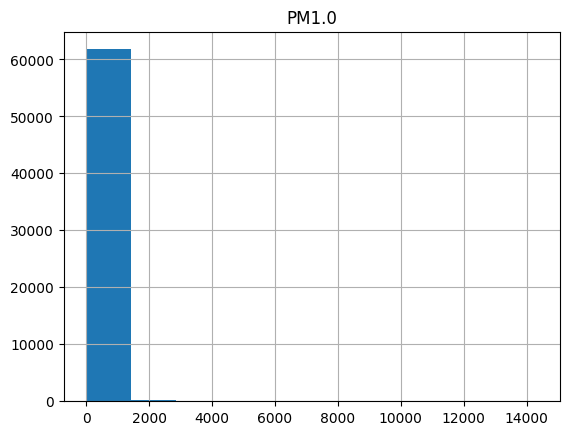

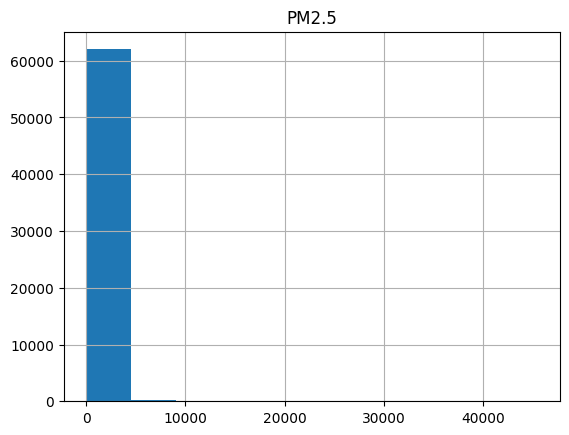

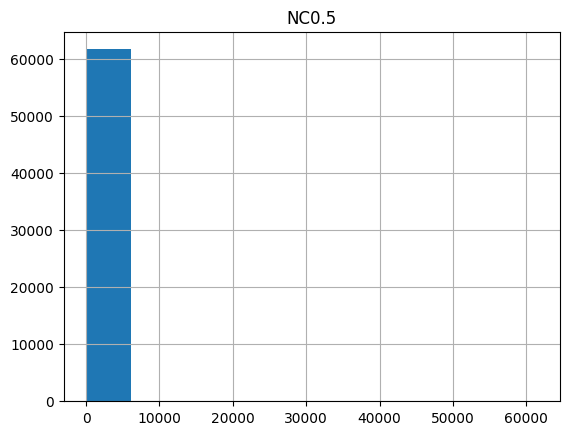

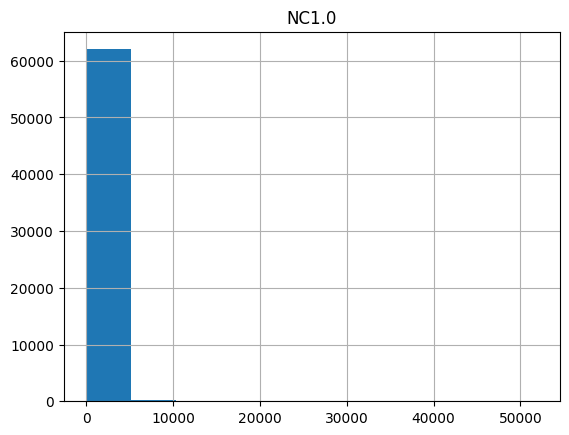

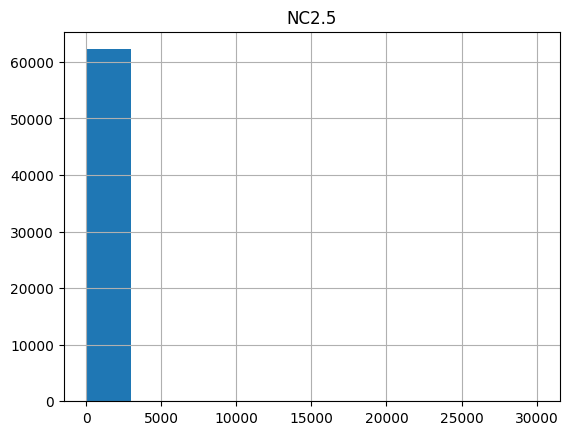

In [116]:
columns = ['TVOC[ppb]','eCO2[ppm]','PM1.0','PM2.5','NC0.5', 'NC1.0', 'NC2.5']

for column in columns:
    data.hist(column)

## Изучение основных параметров без выбросов

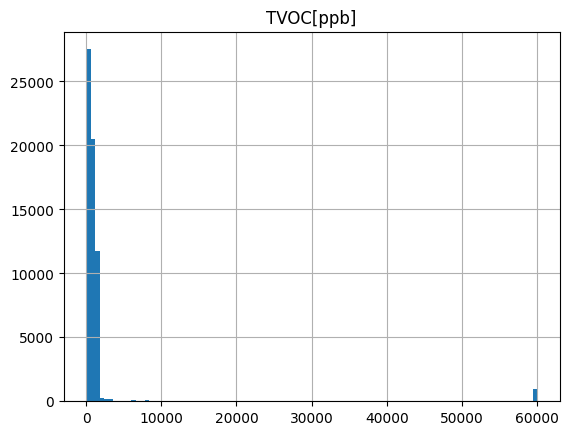

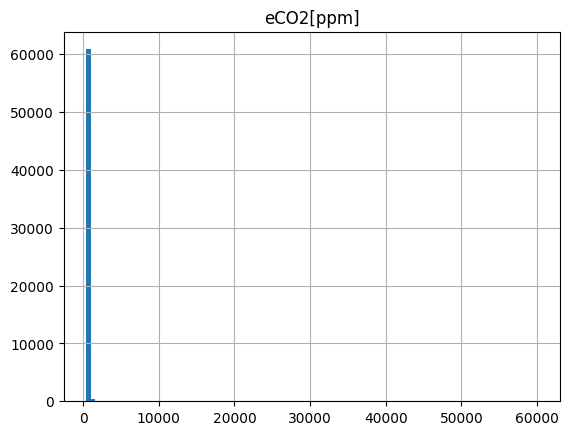

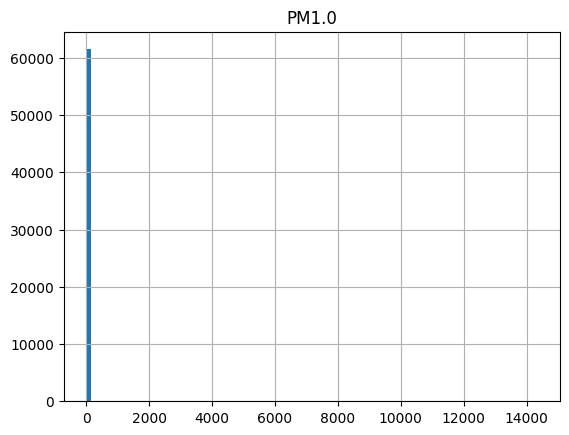

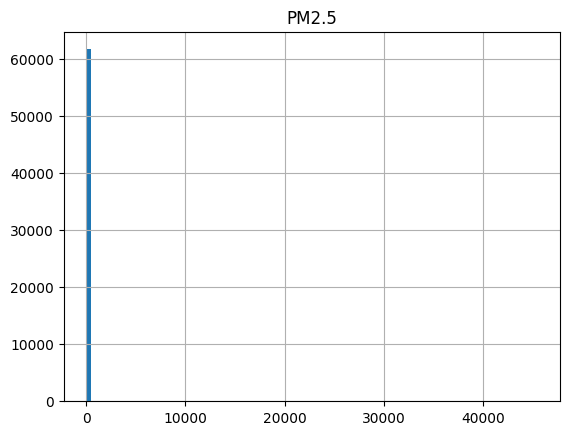

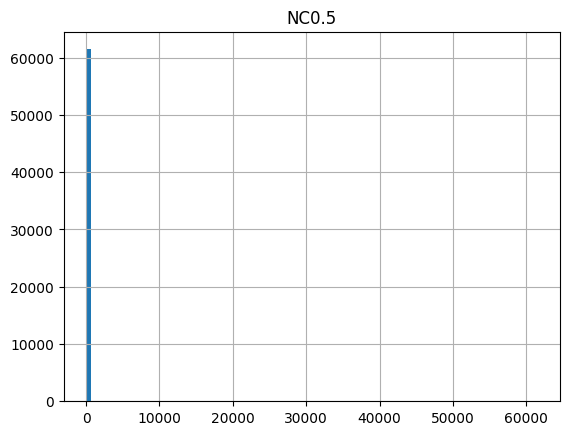

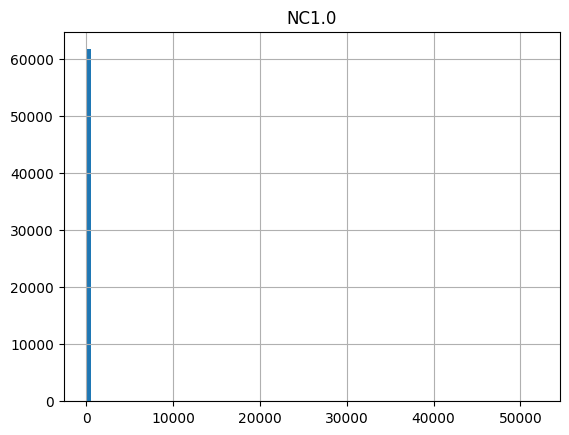

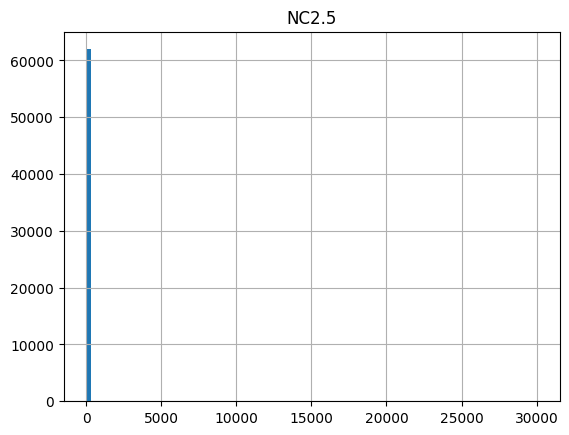

In [117]:
columns = ['TVOC[ppb]','eCO2[ppm]','PM1.0','PM2.5','NC0.5', 'NC1.0', 'NC2.5']

for column in columns:
    data.hist(column, bins=100)

### Анализ данных в момент срабатывания датчика

In [135]:
fire_alarm_true = data[data["Fire Alarm"] == True]
fire_alarm_false = data[data["Fire Alarm"] == False]
fire_alarm_true.sort_values(by='Temperature[C]', ascending=False).head(30)

,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,Fire Alarm
50544,2022-06-10 23:26:01,41.41,13.57,0,1523,12833,20239,930.917,0.90,0.93,6.19,0.965,0.022,True
50542,2022-06-10 23:25:59,41.37,13.59,0,1657,12805,20157,930.894,0.86,0.89,5.89,0.919,0.021,True
50543,2022-06-10 23:26:00,41.37,13.60,0,1345,12936,20211,930.904,0.89,0.92,6.12,0.954,0.022,True
50541,2022-06-10 23:25:58,41.34,13.47,659,2095,12734,20083,930.899,0.85,0.88,5.85,0.912,0.021,True
50536,2022-06-10 23:25:53,41.32,13.94,195,3454,12516,19921,930.898,0.90,0.93,6.19,0.966,0.022,True
50540,2022-06-10 23:25:57,41.32,13.42,84,2374,12690,20030,930.889,0.84,0.87,5.76,0.898,0.020,True
50489,2022-06-10 23:25:06,41.31,13.76,308,8391,12071,19812,930.907,1.33,1.39,9.19,1.432,0.032,True
50537,2022-06-10 23:25:54,41.31,13.84,197,4351,12371,19913,930.903,0.89,0.92,6.12,0.955,0.022,True
50490,2022-06-10 23:25:07,41.31,13.88,376,10940,11949,19731,930.908,1.32,1.37,9.10,1.418,0.032,True
50487,2022-06-10 23:25:04,41.28,13.89,346,9788,12012,19761,930.914,1.43,1.49,9.87,1.539,0.035,True


In [138]:
fire_alarm_false.sort_values(by='Temperature[C]', ascending=False).head(50)

,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,Fire Alarm
56408,2022-06-08 19:44:13,59.93,10.91,60000,3835,11849,17314,936.738,2038.11,2611.62,12786.02,2778.346,529.022,False
56407,2022-06-08 19:44:12,59.93,11.01,60000,4007,11821,17295,936.755,1595.80,2045.90,10008.56,2176.653,415.238,False
56409,2022-06-08 19:44:14,59.89,11.03,60000,3567,11876,17347,936.736,2768.76,3528.73,17417.89,3751.480,700.092,False
56406,2022-06-08 19:44:11,59.89,11.23,60000,3818,11846,17318,936.761,463.79,577.02,2953.01,611.580,103.613,False
56404,2022-06-08 19:44:09,59.86,11.18,60000,4719,11716,17199,936.762,607.37,753.73,3872.03,798.600,133.815,False
56405,2022-06-08 19:44:10,59.85,11.31,60000,1565,12201,17758,936.766,439.28,1.76,2803.80,575.983,95.482,False
56403,2022-06-08 19:44:08,59.79,11.30,60000,4899,11673,17164,936.750,632.22,787.48,4023.14,834.758,142.119,False
56401,2022-06-08 19:44:06,59.77,11.50,60000,1892,12158,17705,936.727,862.89,1088.07,5457.60,1155.203,206.862,False
56400,2022-06-08 19:44:05,59.75,11.52,60000,3134,11959,17448,936.727,1241.84,1577.37,7825.68,1676.226,308.821,False
56402,2022-06-08 19:44:07,59.75,11.58,60000,3689,11865,17360,936.742,789.77,992.30,5004.16,1053.041,185.862,False


In [119]:
# mode_true = fire_alarm_true.mode().iloc[0]
# mode_false = fire_alarm_false.mode().iloc[0]

# most_true = mode_true.to_dict()
# most_false = mode_false.to_dict()
# most_true

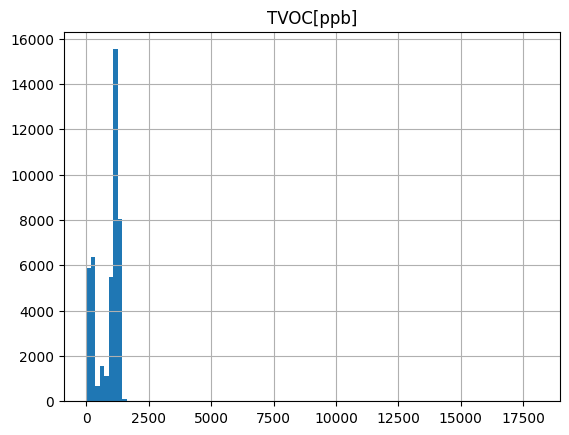

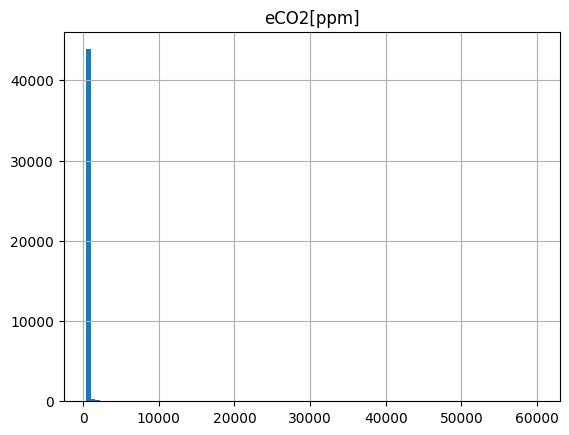

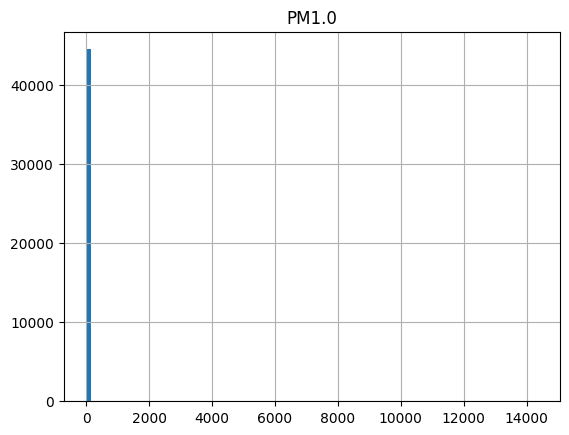

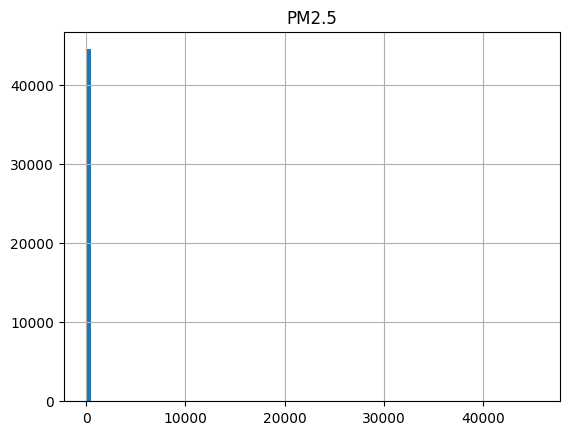

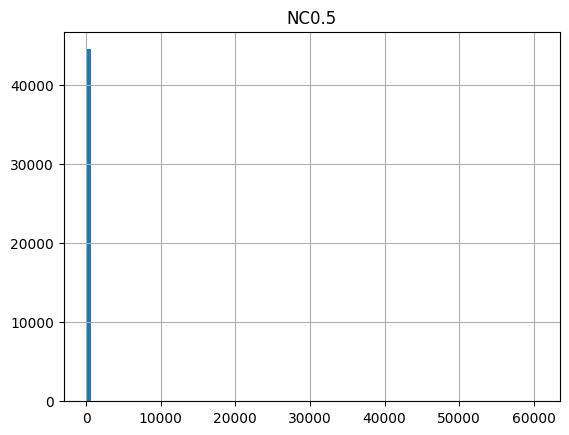

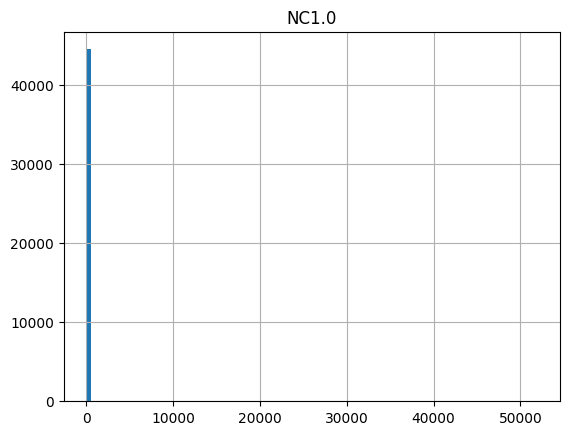

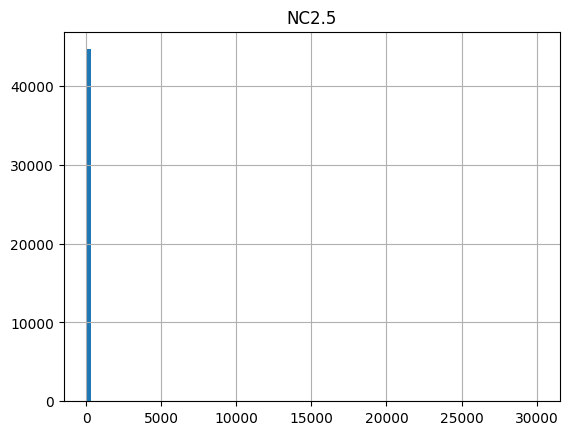

In [121]:
columns = ['TVOC[ppb]','eCO2[ppm]','PM1.0','PM2.5','NC0.5', 'NC1.0', 'NC2.5']

for column in columns:
    fire_alarm_true.hist(column, bins=100)

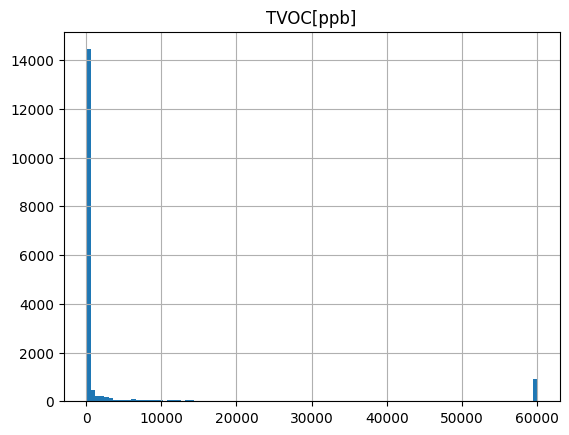

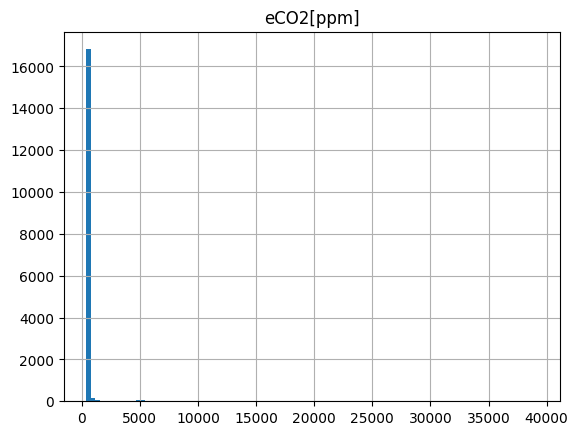

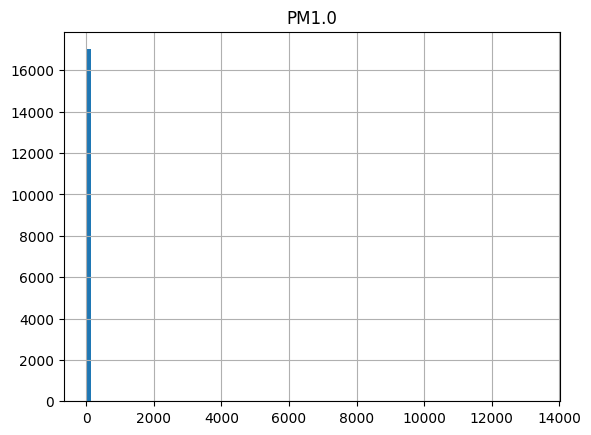

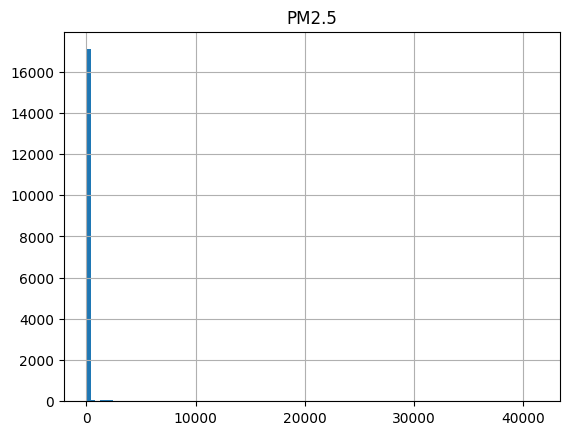

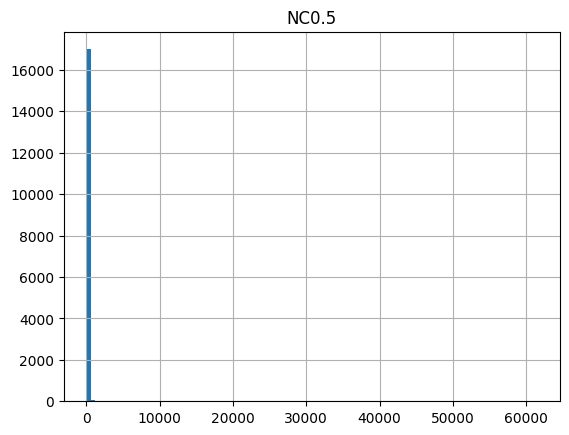

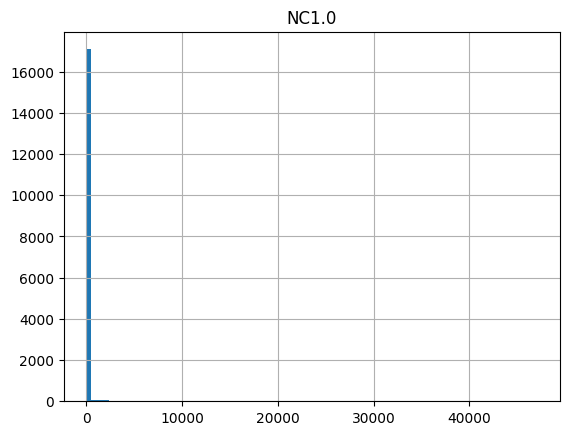

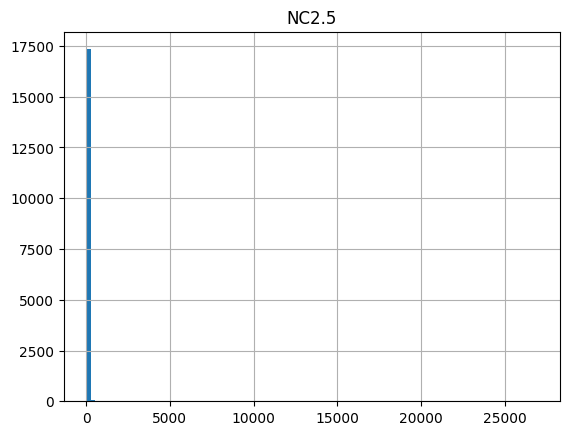

In [122]:
columns = ['TVOC[ppb]','eCO2[ppm]','PM1.0','PM2.5','NC0.5', 'NC1.0', 'NC2.5']

for column in columns:
    fire_alarm_false.hist(column, bins=100)